# **Clustering Model Training Notebook**



---
## 0. Setup Environment

### 0.a Install Mandatory Packages

> Do not modify this code before running it

In [1]:
# Do not modify this code

import os
import sys
from pathlib import Path

COURSE = "36106"
ASSIGNMENT = "AT3"
DATA = "data"

asgmt_path = f"{COURSE}/assignment/{ASSIGNMENT}"
root_path = "./"

#print("###### Install required Python packages ######")
! pip install -q -r https://raw.githubusercontent.com/aso-uts/labs_datasets/main/36106-mlaa/requirements.txt

if os.getenv("COLAB_RELEASE_TAG"):

    from google.colab import drive
    from pathlib import Path

    #print("\n###### Connect to personal Google Drive ######")
    gdrive_path = "/content/gdrive"
    drive.mount(gdrive_path)
    root_path = f"{gdrive_path}/MyDrive/"

print("\n###### Setting up folders ######")
folder_path = Path(f"{root_path}/{asgmt_path}/") / DATA
folder_path.mkdir(parents=True, exist_ok=True)
print(f"\nYou can now save your data files in: {folder_path}")

if os.getenv("COLAB_RELEASE_TAG"):
    %cd {folder_path}

from IPython.display import display, HTML

def print_tile(key, value, size="h1"):
  return display(HTML(f"""<p style="color:grey">{key}</p><{size} font-size: 3em>{value}</{size}>"""))

Mounted at /content/gdrive

###### Setting up folders ######

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data
/content/gdrive/MyDrive/36106/assignment/AT3/data


### 0.b Disable Warnings Messages

> Do not modify this code before running it

In [2]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 0.c Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.d Import Packages

In [65]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

---
## A. Project Description


In [4]:
# <Student to fill this section>
group_name = "Group 18"
student_name = "Rasyid Sahindra"
student_id = "25510254"

In [5]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [6]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [7]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## B. Business Understanding

In [9]:
# <Student to fill this section>
business_use_case_description = """
Telecom company use machine learning method to segment telecom customers into distinct behavioral and value-based clusters.
This project approach enables targeted marketing, personalized services, and optimized retention strategies.
"""

In [10]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [8]:
# <Student to fill this section>
business_objectives = """
We segment telecom customers based on monthly revenue, data usage, tenure, and service adoption using clustering
techniques. This helps identify high-value users, heavy data consumers, and potential customers for
targeted marketing and retention.
"""

In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [127]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
1. This project result will identify customer groups for personalized campaigns, the clusters reveal high-spenders,
data lovers, and loyal users for targeted promos fro Marketing Teams, sales, and finance.
2. This project result will understand service usage trends, The	clustering shows which segments prefer
unlimited data, tech support, etc for product teams
"""

In [128]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets

In [12]:
# <Student to fill this section>
try:
  df = pd.read_csv(folder_path / "df_customer_subscriptions_cleaned.csv")
except Exception as e:
  print(e)

In [13]:
# <Student to fill this section>
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   Unnamed: 0                         7043 non-null   float64
 2   number_referrals                   7043 non-null   float64
 3   month_tenure                       7043 non-null   float64
 4   has_referred_friend                7043 non-null   object 
 5   plan                               7043 non-null   object 
 6   phone_plan                         7043 non-null   object 
 7   has_multiple_lines                 7043 non-null   object 
 8   broadband_plan                     7043 non-null   object 
 9   broadband_type                     7043 non-null   object 
 10  online_security                    7043 non-null   object 
 11  online_backup                      7043 non-null   objec

In [14]:
# <Student to fill this section>
df.head()

,customer_id,Unnamed: 0,number_referrals,month_tenure,has_referred_friend,plan,phone_plan,has_multiple_lines,broadband_plan,broadband_type,...,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,nps,cltv,age,is_young_adult,is_senior,revenue_per_month
0,000f51ad-8208-46f4-a213-6b83de3dded1,11789.0,0.0,39.0,No,Unknown,Yes,No,No,Unknown,...,0.00,0.0,1161.81,1924.26,4.0,3733.0,23.0,Yes,No,49.340000
1,001a6be8-e23e-47e1-8384-18051f2d03b5,5874.0,6.0,72.0,Unknown,Unknown,Yes,Yes,No,Unknown,...,0.00,0.0,1306.08,2929.23,5.0,4152.0,26.0,Yes,No,40.683750
2,001af11c-af9e-44eb-9c32-15f6d1d62efe,5951.0,1.0,71.0,Yes,Plan A,Yes,Yes,Yes,DSL,...,0.00,0.0,1307.82,7633.07,4.0,6483.0,31.0,No,No,107.508028
3,001d7af4-9227-4d52-89e6-b89b04f55224,7135.0,3.0,65.0,Unknown,Plan B,Yes,Yes,Yes,Fiber Optic,...,0.00,0.0,0.00,7981.75,1.0,4196.0,78.0,No,Yes,122.796154
4,00256988-b4d0-45f3-9351-be803389701e,8710.0,2.0,42.0,Unknown,Plan B,Yes,Yes,Yes,Cable,...,28.49,0.0,453.18,2130.44,2.0,4873.0,30.0,No,No,50.724762


### C.2 Define Target variable

In [17]:
# <Student to fill this section>
target_definition_explanations = """
Not Applicable. Clustering is an unsupervised learning technique, which means it does not require a target variable.
Instead of predicting a specific outcome, clustering automatically groups customers based on similarities in
their behavior, usage, or demographics. This allows us to discover hidden patterns and customer segments
without predefined labels.
"""

In [18]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [19]:
# <Student to fill this section>

target_name = 'y'

### C.4 Explore Target variable

In [ ]:
# <Student to fill this section>


In [20]:
# <Student to fill this section>
target_distribution_explanations = """
Not Applicable. Clustering is an unsupervised learning technique, which means it does not require a target variable.
Instead of predicting a specific outcome, clustering automatically groups customers based on similarities in
their behavior, usage, or demographics. This allows us to discover hidden patterns and customer segments
without predefined labels.
"""

In [21]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest 1

> You can add more cells in this section

In [ ]:
# <Student to fill this section>

In [24]:
# <Student to fill this section>
feature1_insights = """
Exploration of Feature of Interest already performed within EDA process.
We explored Financial Features: `total_revenue`, `total_charges`, `monthly_charges`, `monthly_international_charges`
and Customer Features: `month_tenure`, `cltv`, `avg_monthly_download_in_gb`, `age`
"""

In [25]:
# Do not modify this code
print_tile(size="h3", key='feature1_insights', value=feature1_insights)

### C.6 Explore Feature of Interest 2

> You can add more cells in this section

In [ ]:
# <Student to fill this section>

In [26]:
# <Student to fill this section>
feature_2_insights = """
Exploration of Feature of Interest already performed within EDA process.
We explored Financial Features: `total_revenue`, `total_charges`, `monthly_charges`, `monthly_international_charges`
and Customer Features: `month_tenure`, `cltv`, `avg_monthly_download_in_gb`, `age`
"""

In [27]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.6 Explore Feature of Interest n

> You can add more cells in this section

In [ ]:
# <Student to fill this section>

In [28]:
# <Student to fill this section>
feature_n_insights = """
Exploration of Feature of Interest already performed within EDA process.
We explored Financial Features: `total_revenue`, `total_charges`, `monthly_charges`, `monthly_international_charges`
and Customer Features: `month_tenure`, `cltv`, `avg_monthly_download_in_gb`, `age`
"""

In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection


In [73]:
# <Student to fill this section>

features_list = [ 'month_tenure',
       'phone_plan', 'has_multiple_lines',
       'broadband_plan', 'online_security', 'online_backup',
       'device_protection', 'premium_tech_support', 'unlimited_data',
       'paperless_billing',
       'avg_monthly_international_charges', 'avg_monthly_download_in_gb',
       'monthly_charge', 'total_refunds',
       'total_extra_data_charges', 'total_international_charges',
       'total_revenue', 'nps', 'cltv', 'age', 'is_young_adult', 'is_senior',
       'revenue_per_month']

In [74]:
df.columns

Index(['customer_id', 'Unnamed: 0', 'number_referrals', 'month_tenure',
       'has_referred_friend', 'plan', 'phone_plan', 'has_multiple_lines',
       'broadband_plan', 'broadband_type', 'online_security', 'online_backup',
       'device_protection', 'premium_tech_support', 'unlimited_data',
       'contract', 'paperless_billing', 'payment_method',
       'avg_monthly_international_charges', 'avg_monthly_download_in_gb',
       'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_international_charges',
       'total_revenue', 'nps', 'cltv', 'age', 'is_young_adult', 'is_senior',
       'revenue_per_month'],
      dtype='object')

In [75]:
df[features_list].describe(include='object').transpose()

,count,unique,top,freq
phone_plan,7043,2,Yes,6361
has_multiple_lines,7043,2,No,4072
broadband_plan,7043,2,Yes,5517
online_security,7043,2,No,5024
online_backup,7043,2,No,4614
device_protection,7043,2,No,4621
premium_tech_support,7043,2,No,4999
paperless_billing,7043,2,Yes,4171
is_young_adult,7043,2,No,5642
is_senior,7043,2,No,5901


In [76]:
# <Student to fill this section>
feature_selection_insights = """
we eliminate irrelevant features for clustering from original dataset: customer_id, Unnamed: 0
and also eliminate features that has many categorical values (not useful for clustering): plan, payment_method, contract
redundant features: broadband_type (redundant with broadband plan), total_charges (highly correlated with total_revenue, we need to keep only one)
imbalance categorical features (too many zero): number_referrals (and redundant with has refered friend).
we keep the rest
"""

In [35]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_insights', value=feature_selection_insights)

---
## E. Data Preparation

### E.1 Data Transformation Encoding and Scaling Features

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts

In [78]:
# <Student to fill this section>
#data transformation encoding the Yes/No features into binary values.

df_trans = df[features_list].copy()

binary_columns = ['phone_plan', 'has_multiple_lines', 'broadband_plan',
                  'online_security', 'online_backup', 'device_protection', 'premium_tech_support',
                  'unlimited_data', 'paperless_billing', 'is_young_adult', 'is_senior']

# Map 'Yes'/'No' to 1/0
for col in binary_columns:
    if df_trans[col].dtype == 'object':
        df_trans[col] = df_trans[col].map({'Yes': 1, 'No': 0})

# Scale numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_trans), columns=df_trans.columns)


In [79]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   month_tenure                       7043 non-null   float64
 1   phone_plan                         7043 non-null   float64
 2   has_multiple_lines                 7043 non-null   float64
 3   broadband_plan                     7043 non-null   float64
 4   online_security                    7043 non-null   float64
 5   online_backup                      7043 non-null   float64
 6   device_protection                  7043 non-null   float64
 7   premium_tech_support               7043 non-null   float64
 8   unlimited_data                     7043 non-null   float64
 9   paperless_billing                  7043 non-null   float64
 10  avg_monthly_international_charges  7043 non-null   float64
 11  avg_monthly_download_in_gb         7043 non-null   float

In [80]:
df_scaled.head()

,month_tenure,phone_plan,has_multiple_lines,broadband_plan,online_security,online_backup,device_protection,premium_tech_support,unlimited_data,paperless_billing,...,total_refunds,total_extra_data_charges,total_international_charges,total_revenue,nps,cltv,age,is_young_adult,is_senior,revenue_per_month
0,0.269433,0.327438,-0.854176,-1.901403,-0.633933,-0.725563,-0.723968,-0.639439,-1.408211,-1.205113,...,-0.244589,-0.271604,0.600463,-0.363726,0.628407,-0.564084,-1.403636,2.006769,-0.439916,-0.305850
1,1.614737,0.327438,1.170719,-1.901403,-0.633933,-0.725563,-0.723968,-0.639439,-1.408211,0.829798,...,-0.244589,-0.271604,0.773984,0.020766,1.460650,-0.209891,-1.224522,2.006769,-0.439916,-0.336107
2,1.573970,0.327438,1.170719,0.525927,1.577454,1.378241,1.381277,1.563872,0.710121,-1.205113,...,-0.244589,-0.271604,0.776077,1.820412,0.628407,1.760568,-0.926000,-0.498313,-0.439916,-0.102530
3,1.329370,0.327438,1.170719,0.525927,1.577454,-0.725563,1.381277,-0.639439,0.710121,-1.205113,...,-0.244589,-0.271604,-0.796907,1.953814,-1.868323,-0.172697,1.880110,-0.498313,2.273159,-0.049092
4,0.391733,0.327438,1.170719,0.525927,-0.633933,-0.725563,-0.723968,-0.639439,0.710121,0.829798,...,3.422279,-0.271604,-0.251844,-0.284844,-1.036080,0.399590,-0.985705,-0.498313,-0.439916,-0.301010


In [45]:
# <Student to fill this section>
data_cleaning_1_explanations = """
1. Clustering algorithms require all features to be numerical to compute distances between data points.
2. Encoding is needed to convert binary and categorical features (like 'Yes'/'No') into numerical values
so clustering algorithms can process them.
3. Scaling ensures that all features contribute equally by standardizing their range,
preventing high-value features from dominating the clustering results.
"""

In [46]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [53]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Already performed in previous section
"""

In [54]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation <put_name_here>

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [55]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Already performed in previous section
"""

In [56]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# <Student to fill this section>

In [47]:
# <Student to fill this section>
feature_engineering_1_explanations = """
New Feature already created in previous EDA process. Created revenue_per_month feature.
"""

In [48]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# <Student to fill this section>

In [49]:
# <Student to fill this section>
feature_engineering_2_explanations = """
New Feature already created in previous EDA process. Created revenue_per_month feature.
"""

In [50]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "\<put_name_here\>"

> Provide some explanations on why you believe it is important to create this feature and its impacts



In [ ]:
# <Student to fill this section>

In [51]:
# <Student to fill this section>
feature_engineering_3_explanations = """
New Feature already created in previous EDA process. Created revenue_per_month feature.
"""

In [52]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

> Provide some explanations on what is the best strategy to use for data splitting for this dataset


In [ ]:
# <Student to fill this section>

In [57]:
# <Student to fill this section>
data_splitting_explanations = """
Not Applicable. Clustering is an unsupervised learning technique, which means it does not require to split dataset.
Instead of predicting a specific outcome, clustering automatically groups customers based on similarities in
their behavior, usage, or demographics. This allows us to discover hidden patterns and customer segments
without predefined labels.
"""

In [58]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [59]:
# <Student to fill this section>
data_transformation_1_explanations = """
Already performed in previous section
"""

In [60]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [61]:
# <Student to fill this section>
data_transformation_2_explanations = """
Already performed in previous section
"""

In [62]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "\<put_name_here\>"

> Provide some explanations on why you believe it is important to perform this data transformation and its impacts


In [ ]:
# <Student to fill this section>

In [63]:
# <Student to fill this section>
data_transformation_3_explanations = """
Already performed in previous section
"""

In [64]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

> Do not change this code

In [ ]:
# Do not modify this code
# Save training set
#try:
  #X_train.to_csv(folder_path / 'X_train.csv', index=False)
  #y_train.to_csv(folder_path / 'y_train.csv', index=False)
#except Exception as e:
  #print(e)

name 'X_train' is not defined


In [ ]:
# Do not modify this code
# Save training set
#try:
  #X_val.to_csv(folder_path / 'X_val.csv', index=False)
  #y_val.to_csv(folder_path / 'y_val.csv', index=False)
#except Exception as e:
  #print(e)

name 'X_val' is not defined


In [ ]:
# Do not modify this code
# Save training set
#try:
  #X_test.to_csv(folder_path / 'X_test.csv', index=False)
  #y_test.to_csv(folder_path / 'y_test.csv', index=False)
#except Exception as e:
  #print(e)

name 'X_test' is not defined


---
## I. Assess Baseline Model

### I.1 Generate Predictions with Baseline Model

In [ ]:
# <Student to fill this section>

### I.2 Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate


In [ ]:
# <Student to fill this section>

In [100]:
# <Student to fill this section>
performance_metrics_explanations = """
Not Applicable as we use clustering method.
"""

In [101]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

### I.3 Baseline Model Performance

> Provide some explanations on model performance


In [ ]:
# <Student to fill this section>

In [102]:
# <Student to fill this section>
baseline_performance_explanations = """
Not Applicable as we use clustering method.

"""

In [103]:
# Do not modify this code
print_tile(size="h3", key='baseline_performance_explanations', value=baseline_performance_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [112]:
# <Student to fill this section>
from sklearn.cluster import KMeans

In [113]:
# <Student to fill this section>
algorithm_selection_explanations = """
KMeans is used because it efficiently groups customers based on similarity in their numeric features,
allowing us to discover meaningful segments without predefined labels. It is simple, scalable,
and well-suited for large datasets with continuous variables like revenue, usage, and tenure.
"""

In [114]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


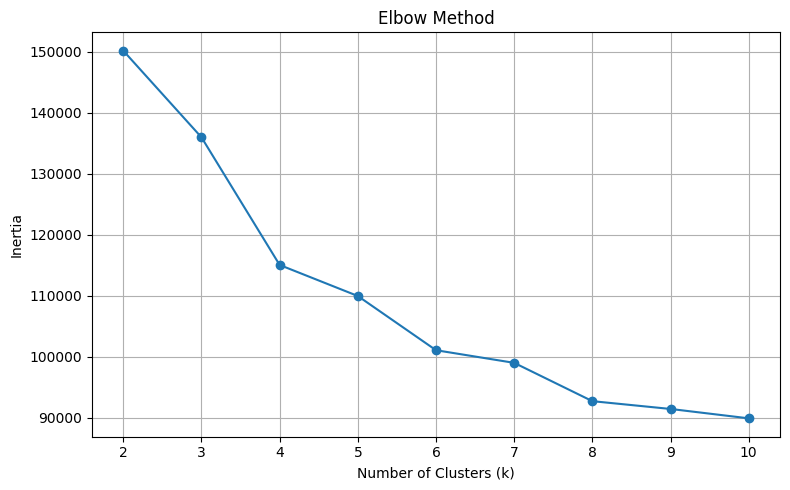

In [108]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
# <Student to fill this section>
#we use number of cluster = 5 as this is the most optimal based on elbow chart result.

kmeans = KMeans(n_clusters=5, random_state=42)
df_scaled['cluster'] = kmeans.fit_predict(df_scaled)

In [115]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Based on the Elbow Method plot result, 5 clusters is a reasonable choice because it is the point where
the rate of decrease in inertia begins to slow down and Using random_state=42 ensures reproducibility of the clustering results.

"""

In [116]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

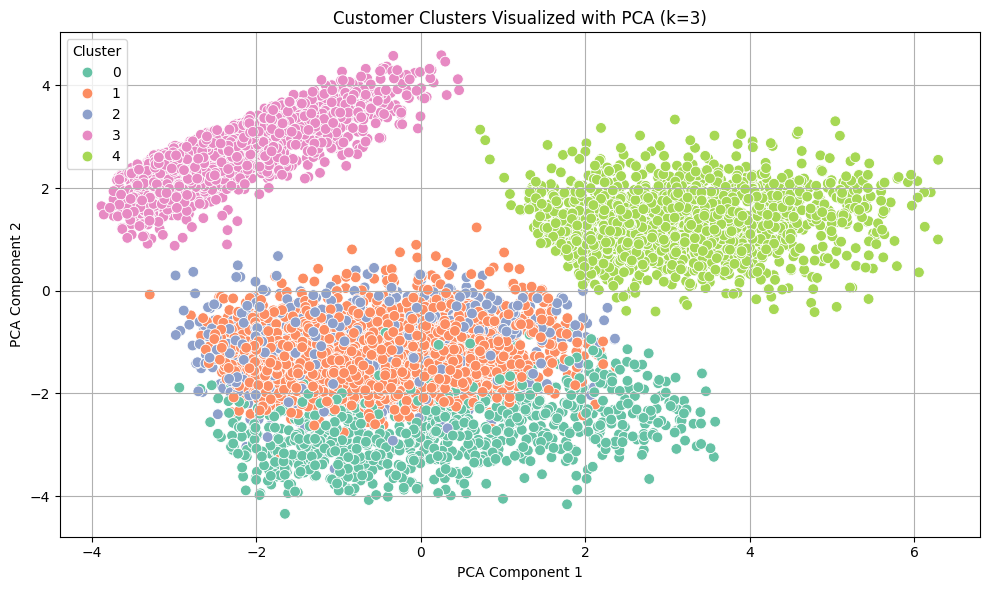

In [117]:
# <Student to fill this section>
from sklearn.decomposition import PCA

# Reduce the dimensionality to 2D for visualization
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(df_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=df_scaled['cluster'], palette='Set2', s=60)
plt.title('Customer Clusters Visualized with PCA (k=3)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [106]:
# <Student to fill this section>
cluster_summary = df_scaled.groupby('cluster').mean()
print(cluster_summary)

         month_tenure  phone_plan  has_multiple_lines  broadband_plan  \
cluster                                                                 
0           -0.101855    0.327438            0.112089        0.525927   
1           -0.600618    0.327438            0.009757        0.524941   
2           -0.025439   -3.054010           -0.854176        0.525927   
3           -0.073308    0.327438           -0.400663       -1.898224   
4            1.116270    0.327438            0.707847        0.525927   

         online_security  online_backup  device_protection  \
cluster                                                      
0               0.198893       0.172552           0.162451   
1              -0.178357      -0.166486          -0.155098   
2               0.283695       0.159762           0.217528   
3              -0.633933      -0.725563          -0.723968   
4               0.687363       0.830808           0.790477   

         premium_tech_support  unlimited_data  paperl

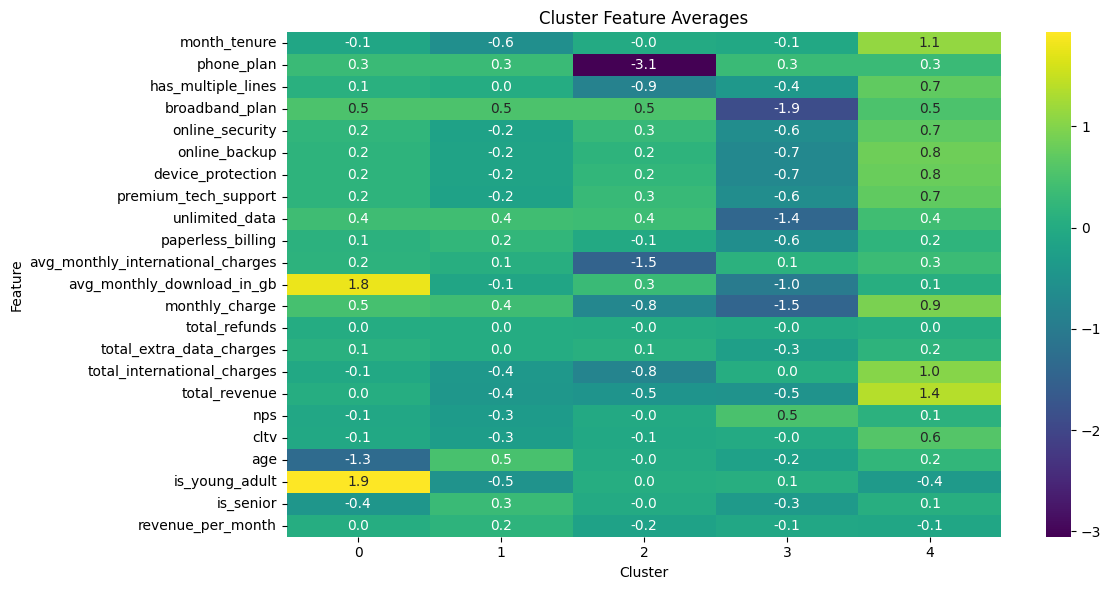

In [107]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary.T, cmap='viridis', annot=True, fmt=".1f")
plt.title("Cluster Feature Averages")
plt.ylabel("Feature")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()

In [119]:
# <Student to fill this section>
model_performance_explanations = """
Result:
Cluster 0: This cluster consists of extremely high data consumption (avg_monthly_download_in_gb)
and the highest scores for is_young_adult. They tend to subscribe to unlimited data plans and maintain
slightly above-average monthly charges. These customers are highly digital, likely streaming-heavy users,
mobile-first, and very engaged online.

Cluster 1:
Customers in this cluster are older, long-term subscribers with the highest values in month_tenure, monthly_charge, cltv,
and total_revenue. They consistently adopt premium services such as online security, backups, and international calling. This
indicates a stable, high-value segment.

Cluster 2:
This group exhibits near-average values across most features with a few service engagement and spending.
Their age distribution is more balanced, and while they don't heavily adopt premium services, they aren't completely disengaged either.
They represent a broad middle-ground segment that may be under-marketed.

Cluster 3:
Though this cluster includes younger individuals, they show relatively high monthly_charge without a corresponding spike in service usage
or loyalty metrics. While some digital features are present, the cluster does not fully engage with high-value offerings.
This mismatch suggests possible dissatisfaction or misalignment between pricing and perceived value.

Cluster 4:
This cluster is dominated by senior users (is_senior) who have the lowest values in data usage, service adoption, and monthly charges.
Their engagement across most digital or premium services is minimal. While they bring in relatively low revenue, they may still represent
a stable base.
"""

In [120]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
# <Student to fill this section>

In [121]:
# <Student to fill this section>
business_impacts_explanations = """
The clustering result generate insights to business (Marketing Team/Product Team), for example:
1. Cluster 0: Offer high-speed data bundles and digital perks to retain and upsell tech-savvy, data-heavy young users.
2. Cluster 1: Reward loyalty with premium benefits or personalized offers to maintain high-value, long-tenured customers.
3. Cluster 2: Introduce targeted promotions or light engagement campaigns to activate moderate-value.
4. Cluster 3: Help these customers get more value for their money by offering better service bundles and
clearer guidance on how to use their plan benefits.
5. Cluster 4: Maintain simple, affordable plans and proactive support for senior, low-usage customers.
"""

In [122]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [123]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Confirmed" # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [124]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [125]:
# <Student to fill this section>
experiment_results_explanations = """
This project succesfully clusters/segments customers based on their behavior data and information. This will make business member
(Marketing Team/Product Team) may use the insights for Promotional Enhancements.
"""

In [126]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)